**Actividad 4.- Transformadas geométricas y de Fourier**

In [2]:
#importar librerías
import cv2,urllib.request,numpy as np,matplotlib.pyplot as plt

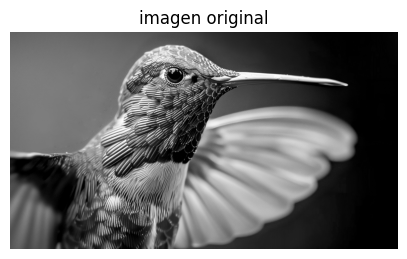

In [3]:
#cargar la imagen
url = 'https://raw.githubusercontent.com/dilp90/PDI/main/Imagenes/colibri.jpg'

urllib.request.urlretrieve(url,'colibri.jpg')
img = cv2.imread('colibri.jpg',cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5,5))
plt.imshow(img,cmap='gray')
plt.title('imagen original')
plt.axis('off')
plt.show()

Se descargó la imagen y se cargó en escala de grises para simplificar el procesamiento. Después se visualizó para verificar que se leyó correctamente.

In [4]:
#transformaciones geométricas
filas,columnas = img.shape

#traslación
M_tras = np.float32([[1,0,80],[0,1,50]])
traslacion = cv2.warpAffine(img,M_tras,(columnas,filas))

#escalado
escalado = cv2.resize(img,None,fx=1.5,fy=1.5,interpolation=cv2.INTER_LINEAR)

#rotación
M_rot = cv2.getRotationMatrix2D((columnas/2,filas/2),45,1)
rotacion = cv2.warpAffine(img,M_rot,(columnas,filas))

#reflexión
reflexion = cv2.flip(img,1)

Se aplicaron una traslación, un escalado, una rotación y una reflexión utilizando las funciones de OpenCV. Finalmente, se compararon los resultados con la imagen original para observar los cambios.

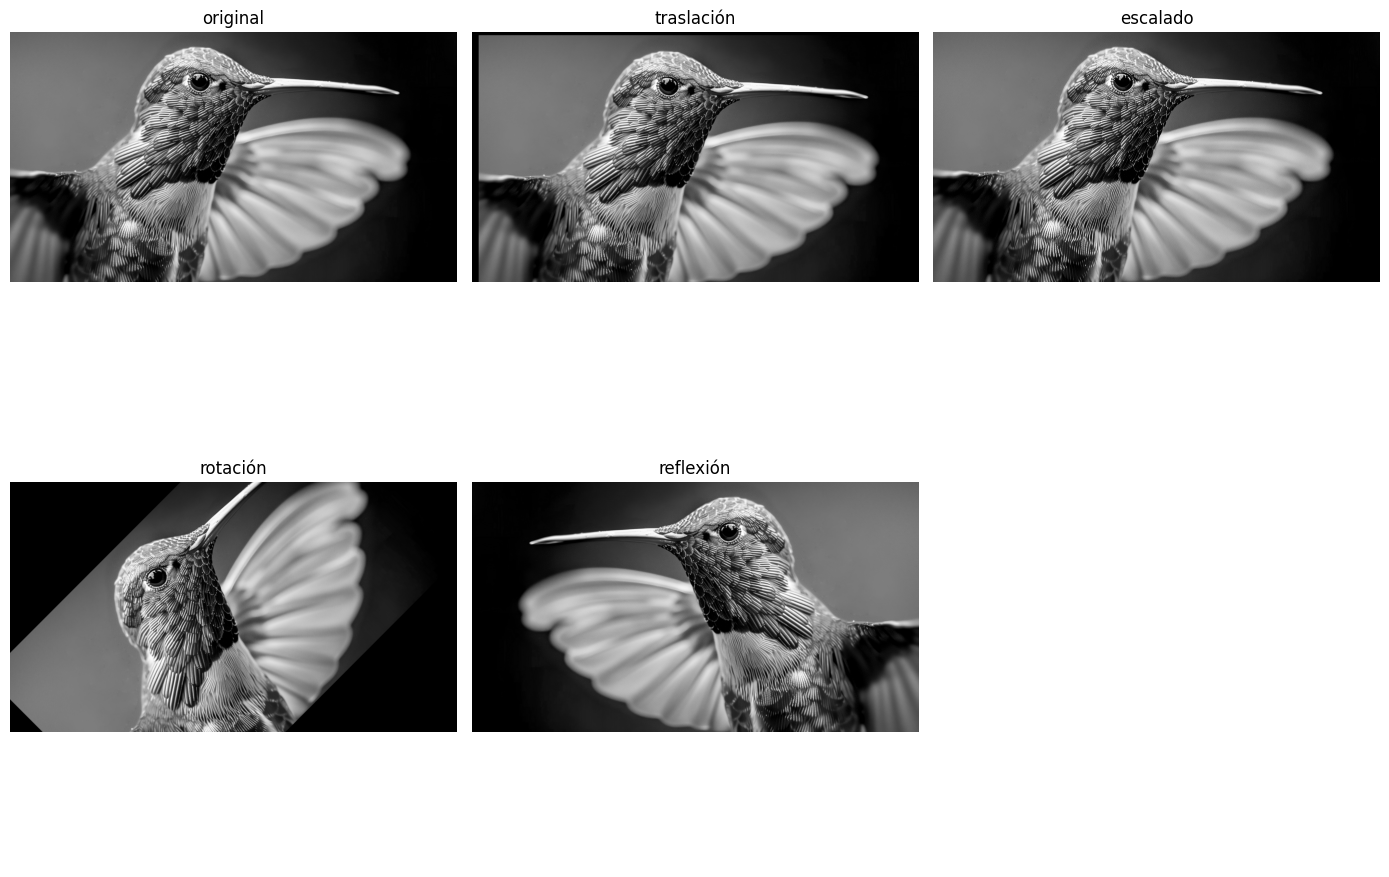

In [5]:
#mostrar resultados
fig,ax = plt.subplots(2,3,figsize=(14,10))

ax[0,0].imshow(img,cmap='gray')
ax[0,0].set_title('original')
ax[0,0].axis('off')

ax[0,1].imshow(traslacion,cmap='gray')
ax[0,1].set_title('traslación')
ax[0,1].axis('off')

ax[0,2].imshow(escalado,cmap='gray')
ax[0,2].set_title('escalado')
ax[0,2].axis('off')

ax[1,0].imshow(rotacion,cmap='gray')
ax[1,0].set_title('rotación')
ax[1,0].axis("off")

ax[1,1].imshow(reflexion,cmap='gray')
ax[1,1].set_title('reflexión')
ax[1,1].axis('off')

ax[1,2].axis('off')

plt.tight_layout()
plt.show()

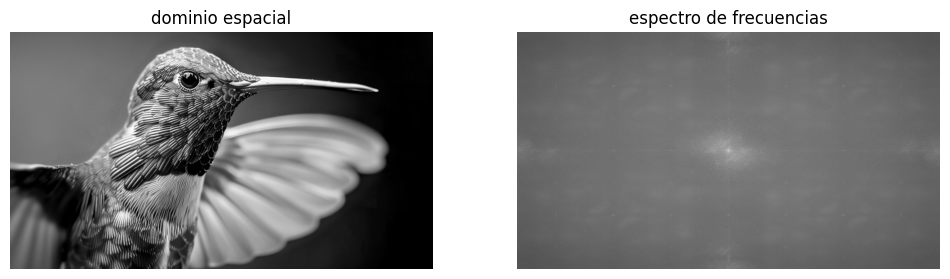

In [6]:
#transformada de fourier
f = np.fft.fft2(img)

fshift = np.fft.fftshift(f)

magnitud = np.log(np.abs(fshift)+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('dominio espacial')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(magnitud,cmap='gray')
plt.title('espectro de frecuencias')
plt.axis("off")

plt.show()

Se calculó la Transformada de Fourier para obtener el espectro de frecuencias de la imagen. También se utilizó fftshift() y np.log() para mejorar su visualización.

In [7]:
#eliminación de ruido por enmascaramiento (filtro paso bajo)

rows,cols = img.shape
crow,ccol = rows//2,cols//2

mask = np.zeros((rows,cols),np.uint8)

radio = 40

Y,X = np.ogrid[:rows,:cols]
distancia = np.sqrt((X-ccol)**2+(Y-crow)**2)

mask[distancia<=radio] = 1
fshift_filtrado = fshift*mask

f_ishift = np.fft.ifftshift(fshift_filtrado)
img_filtrada = np.fft.ifft2(f_ishift)
img_filtrada = np.abs(img_filtrada)

Se aplicó una máscara de paso bajo para conservar las bajas frecuencias y reducir el ruido. Después se reconstruyó la imagen mediante la transformada inversa.

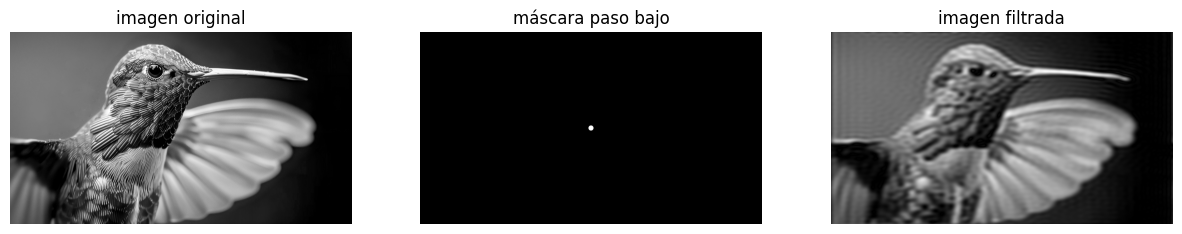

In [8]:
#mostrar filtrado

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img,cmap='gray')
plt.title('imagen original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask,cmap='gray')
plt.title('máscara paso bajo')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_filtrada,cmap='gray')
plt.title('imagen filtrada')
plt.axis('off')

plt.show()